# NB09 — Multi-Crypto Hourly Robustness Test

Question: does the NB08 finding — `hierarchy_rf` adds ~+0.6 pp balanced accuracy and ~+0.006 IC over `baseline_rf` at 1h on BTC-USD — generalize to other crypto tickers, or was it BTC-specific?

**Tickers:** `BTC-USD`, `ETH-USD`, `SOL-USD`, `XRP-USD`. BTC included as a reproducibility anchor for NB08. Crypto-only because stock hourly bars have overnight gaps that would conflate 1h-clock moves with 17.5h overnight gaps.

**Pipeline:** identical to NB08 except multi-ticker and 1h-only.

- `period="720d"`, `interval="1h"` (yfinance hourly limit).
- 5 expanding-window walk-forward folds.
- Hierarchy `max_depth=2` → K=4 leaves (NB07's sweet spot for hierarchy as features).
- RF grid: 4 combos `(max_depth ∈ {6, 10}) × (min_samples_leaf ∈ {20, 50})`, `n_estimators=200`.
- Trivial baselines on every fold: `zero`, `persistence`, `majority`.

**Pass criteria for a robust hierarchy finding:**

1. `hierarchy_rf` IC is positive on at least 3 of 5 folds for each ticker.
2. `hierarchy_rf` balanced accuracy ≥ 50% on average across folds for each ticker.
3. `hierarchy_rf` ≥ `baseline_rf` on at least 3 of 4 tickers (by mean IC and mean balanced accuracy).
4. Mean ROC AUC ≥ 0.51 on each ticker.


In [1]:
import math, os, json, random
from dataclasses import dataclass
from datetime import datetime
from typing import List, Dict, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    accuracy_score, balanced_accuracy_score, roc_auc_score,
)
from scipy.stats import spearmanr

SEED = 42
random.seed(SEED); np.random.seed(SEED)

TICKERS = ["BTC-USD", "ETH-USD", "SOL-USD", "XRP-USD"]
PERIOD = "720d"
INTERVAL = "1h"

HORIZON = 1                  # NB08 showed 4h signal is too noisy; fix at 1h
N_FOLDS = 5
MIN_TRAIN_FRACTION = 0.40
VAL_FRACTION_WITHIN_TRAIN = 0.15
TEST_FRACTION_PER_FOLD = 0.10

MAX_HIERARCHY_DEPTH = 2      # K = 4 leaves
MIN_LEAF_COUNT = 200

RF_N_ESTIMATORS = 200
RF_GRID = [
    {"max_depth": md_, "min_samples_leaf": msl}
    for md_ in (6, 10) for msl in (20, 50)
]

JOURNAL_PATH = "EXPERIMENTS.md"


## Reused machinery from NB08 (compact)


In [2]:
def load_yfinance_hourly(ticker, period, interval):
    raw = yf.download(tickers=ticker, period=period, interval=interval,
                     auto_adjust=True, progress=False, group_by="column")
    if raw.empty:
        raise RuntimeError(f"No data returned for {ticker}")
    if isinstance(raw.columns, pd.MultiIndex):
        raw.columns = [c[0].lower() for c in raw.columns]
    else:
        raw.columns = [str(c).lower() for c in raw.columns]
    df = raw[["open","high","low","close","volume"]].copy().reset_index()
    ts_col = [c for c in df.columns if c not in ("open","high","low","close","volume")][0]
    df = df.rename(columns={ts_col: "ts"})
    df["ts"] = pd.to_datetime(df["ts"], utc=True)
    return df.dropna().sort_values("ts").reset_index(drop=True)


def rolling_zscore(x, w, eps=1e-8):
    m = x.rolling(w, min_periods=max(3, w // 3)).mean()
    s = x.rolling(w, min_periods=max(3, w // 3)).std()
    return (x - m) / (s + eps)


def sigmoid_np(x): return 1.0 / (1.0 + np.exp(-x))


def make_hourly_features(df, horizon):
    out = df.copy()
    for lag in (1, 2, 4, 12, 24, 168):
        out[f"ret_{lag}"] = np.log(out["close"] / out["close"].shift(lag))
    out["range_pct"] = (out["high"] - out["low"]) / out["close"]
    out["open_close_pct"] = (out["close"] - out["open"]) / out["open"]
    for w in (24, 168, 720):
        out[f"vol_{w}"] = out["ret_1"].rolling(w).std()
    for w in (24, 168, 720):
        out[f"ma_{w}"] = out["close"].rolling(w).mean()
        out[f"price_to_ma_{w}"] = out["close"] / out[f"ma_{w}"] - 1.0
    out["volume_log"] = np.log1p(out["volume"])
    out["volume_z_168"] = rolling_zscore(out["volume_log"], 168)
    for w in (168, 720):
        out[f"rolling_max_{w}"] = out["close"].rolling(w).max()
        out[f"drawdown_{w}"] = out["close"] / out[f"rolling_max_{w}"] - 1.0
    out["trend_pressure"] = rolling_zscore(out["ret_168"], 720)
    out["fear_pressure"] = (-4.0*out["drawdown_168"] - 2.0*out["drawdown_720"]
                              + 8.0*out["vol_168"] + 0.35*out["volume_z_168"]
                              - 0.50*out["ret_24"])
    out["greed_pressure"] = (1.50*out["trend_pressure"] + 2.00*out["price_to_ma_168"]
                              + 1.00*out["ret_168"] + 0.20*out["volume_z_168"]
                              - 3.00*out["vol_720"])
    out["fear_index"] = sigmoid_np(out["fear_pressure"].clip(-8, 8))
    out["greed_index"] = sigmoid_np(out["greed_pressure"].clip(-8, 8))
    out[f"future_log_return"] = np.log(out["close"].shift(-horizon) / out["close"])
    out[f"future_direction"] = (out["future_log_return"] > 0).astype(int)
    return out.replace([np.inf, -np.inf], np.nan).dropna().reset_index(drop=True)


BASELINE_FEATURES = [
    "ret_1", "ret_2", "ret_4", "ret_12", "ret_24", "ret_168",
    "range_pct", "open_close_pct",
    "vol_24", "vol_168", "vol_720",
    "price_to_ma_24", "price_to_ma_168", "price_to_ma_720",
    "volume_z_168", "drawdown_168", "drawdown_720",
]


@dataclass
class MeasureNode:
    node_id: str; depth: int
    bounds: Dict[str, Tuple[float, float]]
    mass: float; count: int
    mean: Dict[str, float]
    children: Optional[List["MeasureNode"]] = None
    @property
    def is_leaf(self): return not self.children


def in_bounds(row, bounds):
    for col, (lo, hi) in bounds.items():
        v = float(row[col])
        if not (lo <= v < hi): return False
    return True


def split_node(n, sc, sv):
    lo, hi = n.bounds[sc]
    lb, rb = dict(n.bounds), dict(n.bounds)
    lb[sc] = (lo, sv); rb[sc] = (sv, hi)
    n.children = [
        MeasureNode(n.node_id+"L", n.depth+1, lb, n.mass/2, 0, {}, None),
        MeasureNode(n.node_id+"R", n.depth+1, rb, n.mass/2, 0, {}, None),
    ]
    return n.children


def collect_leaves(n):
    if n.is_leaf: return [n]
    return [l for c in n.children for l in collect_leaves(c)]


def build_hierarchy(train_df, max_depth, min_count):
    feat = ["greed_index", "fear_index"]
    root = MeasureNode("root", 0,
                       {"greed_index":(0.0,1.000001), "fear_index":(0.0,1.000001)},
                       1.0, len(train_df),
                       {c: float(train_df[c].mean()) for c in feat}, None)
    queue = [root]
    while queue:
        n = queue.pop(0)
        if n.depth >= max_depth: continue
        mask = train_df.apply(lambda r: in_bounds(r, n.bounds), axis=1)
        sub = train_df[mask]
        n.count = len(sub); n.mass = n.count / max(len(train_df), 1)
        if n.count < min_count: continue
        v = {c: float(sub[c].var()) for c in feat}
        sc = max(v, key=v.get); sv = float(sub[sc].median())
        if n.bounds[sc][0] < sv < n.bounds[sc][1]:
            queue.extend(split_node(n, sc, sv))
    for leaf in collect_leaves(root):
        mask = train_df.apply(lambda r: in_bounds(r, leaf.bounds), axis=1)
        sub = train_df[mask]
        leaf.count = len(sub); leaf.mass = leaf.count / max(len(train_df), 1)
        leaf.mean = {c: (float(sub[c].mean()) if len(sub) else 0.0) for c in feat}
    return root


def soft_membership(row, leaves, temperature=0.04):
    p = np.array([float(row["greed_index"]), float(row["fear_index"])])
    centers = np.array([[(l.bounds["greed_index"][0]+l.bounds["greed_index"][1])/2,
                          (l.bounds["fear_index"][0]+l.bounds["fear_index"][1])/2]
                         for l in leaves])
    d = np.sum((centers - p[None,:])**2, axis=1)
    logits = -d / max(temperature, 1e-8); logits -= logits.max()
    w = np.exp(logits); return w / w.sum()


def add_memberships(frame, leaves, cols):
    M = np.vstack([soft_membership(r, leaves) for _, r in frame.iterrows()])
    return pd.concat([frame.reset_index(drop=True),
                      pd.DataFrame(M, columns=cols).reset_index(drop=True)], axis=1)


def make_folds(n_rows, n_folds, min_train_fraction, test_fraction_per_fold):
    folds = []
    for i in range(n_folds):
        train_end = int(n_rows * (min_train_fraction + i * test_fraction_per_fold))
        test_end = int(n_rows * (min_train_fraction + (i + 1) * test_fraction_per_fold))
        if test_end > n_rows: test_end = n_rows
        if test_end - train_end < 50: break
        folds.append((train_end, test_end))
    return folds


def _rf_reg(params):
    return RandomForestRegressor(n_estimators=RF_N_ESTIMATORS, random_state=SEED, n_jobs=-1, **params)

def _rf_cls(params):
    return RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=SEED, n_jobs=-1,
                                   class_weight="balanced_subsample", **params)


def select_params(builder, x_tr, y_tr, x_va, y_va, score_fn):
    best, bs = None, -np.inf
    for p in RF_GRID:
        m = builder(p); m.fit(x_tr, y_tr)
        s = score_fn(m, x_va, y_va)
        if s > bs: best, bs = p, s
    return best, bs


def fit_with_val(feature_cols, train_slice, target_col, target_kind):
    n = len(train_slice)
    vs = int(n * (1 - VAL_FRACTION_WITHIN_TRAIN))
    tr, va = train_slice.iloc[:vs], train_slice.iloc[vs:]
    x_tr = tr[feature_cols]; y_tr = tr[target_col]
    x_va = va[feature_cols]; y_va = va[target_col]
    x_full = train_slice[feature_cols]; y_full = train_slice[target_col]
    if target_kind == "regression":
        sf = lambda m, xv, yv: -mean_absolute_error(yv, m.predict(xv))
        best, _ = select_params(_rf_reg, x_tr, y_tr, x_va, y_va, sf)
        m = _rf_reg(best); m.fit(x_full, y_full); return m, best
    else:
        sf = lambda m, xv, yv: balanced_accuracy_score(yv, m.predict(xv))
        best, _ = select_params(_rf_cls, x_tr, y_tr.astype(int), x_va, y_va.astype(int), sf)
        m = _rf_cls(best); m.fit(x_full, y_full.astype(int)); return m, best


def ic(y_true, y_pred):
    if np.std(y_pred) == 0:
        return 0.0
    rho, _ = spearmanr(y_true, y_pred)
    return float(rho) if not np.isnan(rho) else 0.0


## Per-ticker runner


In [3]:
def run_one_fold(df_feat, fold_idx, train_end, test_end):
    train_slice = df_feat.iloc[:train_end].copy()
    test_slice = df_feat.iloc[train_end:test_end].copy()

    root = build_hierarchy(train_slice, MAX_HIERARCHY_DEPTH, MIN_LEAF_COUNT)
    leaves = collect_leaves(root)
    cols = [f"leaf_{l.node_id}" for l in leaves]
    train_m = add_memberships(train_slice, leaves, cols)
    test_m = add_memberships(test_slice, leaves, cols)

    hierarchy_features = BASELINE_FEATURES + cols

    reg_b, _ = fit_with_val(BASELINE_FEATURES, train_m, "future_log_return", "regression")
    cls_b, _ = fit_with_val(BASELINE_FEATURES, train_m, "future_direction", "classification")
    reg_h, _ = fit_with_val(hierarchy_features, train_m, "future_log_return", "regression")
    cls_h, _ = fit_with_val(hierarchy_features, train_m, "future_direction", "classification")

    x_test_b = test_m[BASELINE_FEATURES]; x_test_h = test_m[hierarchy_features]
    y_r = test_m["future_log_return"].to_numpy()
    y_c = test_m["future_direction"].to_numpy().astype(int)

    pr_b = reg_b.predict(x_test_b); pp_b = cls_b.predict_proba(x_test_b)[:, 1]; pc_b = cls_b.predict(x_test_b)
    pr_h = reg_h.predict(x_test_h); pp_h = cls_h.predict_proba(x_test_h)[:, 1]; pc_h = cls_h.predict(x_test_h)

    pr_zero = np.zeros_like(y_r)
    pr_pers = test_m["ret_1"].to_numpy()
    majority = int(train_m["future_direction"].mean() >= 0.5)
    pc_majority = np.full_like(y_c, majority)
    pc_pers = (pr_pers > 0).astype(int)
    pp_pers = np.full_like(y_r, 0.5)

    rows = []
    def reg_row(name, pred):
        rows.append({
            "fold": fold_idx, "model": name, "kind": "regression",
            "mae": float(mean_absolute_error(y_r, pred)),
            "rmse": float(math.sqrt(mean_squared_error(y_r, pred))),
            "ic": ic(y_r, pred), "n_test": len(y_r),
        })
    def cls_row(name, pred, proba=None):
        d = {
            "fold": fold_idx, "model": name, "kind": "classification",
            "accuracy": float(accuracy_score(y_c, pred)),
            "balanced_accuracy": float(balanced_accuracy_score(y_c, pred)),
            "n_test": len(y_c),
        }
        if proba is not None and len(np.unique(y_c)) == 2:
            d["roc_auc"] = float(roc_auc_score(y_c, proba))
        else:
            d["roc_auc"] = float("nan")
        rows.append(d)

    reg_row("zero", pr_zero); reg_row("persistence", pr_pers)
    reg_row("baseline_rf", pr_b); reg_row("hierarchy_rf", pr_h)
    cls_row("majority", pc_majority, pp_pers); cls_row("persistence", pc_pers, pp_pers)
    cls_row("baseline_rf", pc_b, pp_b); cls_row("hierarchy_rf", pc_h, pp_h)

    return pd.DataFrame(rows), {"y_r": y_r, "y_c": y_c, "pr_b": pr_b, "pr_h": pr_h, "pp_b": pp_b, "pp_h": pp_h}


def run_ticker(ticker):
    df_raw = load_yfinance_hourly(ticker, PERIOD, INTERVAL)
    df_feat = make_hourly_features(df_raw, HORIZON)
    print(f"  {ticker}: {len(df_raw)} raw -> {len(df_feat)} bars after dropna, "
          f"{df_feat['ts'].min()} -> {df_feat['ts'].max()}")
    folds = make_folds(len(df_feat), N_FOLDS, MIN_TRAIN_FRACTION, TEST_FRACTION_PER_FOLD)
    rows = []; preds = []
    for i, (tr, te) in enumerate(folds):
        row_df, p = run_one_fold(df_feat, i, tr, te)
        row_df["ticker"] = ticker
        rows.append(row_df); preds.append({"fold": i, "ticker": ticker, **p})
    return pd.concat(rows, ignore_index=True), preds, df_feat


all_rows = []; all_preds_by_ticker = {}
for tk in TICKERS:
    print(f"Running {tk}...")
    df_rows, df_preds, _ = run_ticker(tk)
    all_rows.append(df_rows)
    all_preds_by_ticker[tk] = df_preds

agg = pd.concat(all_rows, ignore_index=True)
agg[["ticker", "fold", "kind", "model", "mae", "rmse", "ic", "accuracy", "balanced_accuracy", "roc_auc", "n_test"]]


Running BTC-USD...


  BTC-USD: 17100 raw -> 16379 bars after dropna, 2024-06-22 00:00:00+00:00 -> 2026-05-12 11:00:00+00:00


Running ETH-USD...


  ETH-USD: 17100 raw -> 16379 bars after dropna, 2024-06-22 00:00:00+00:00 -> 2026-05-12 11:00:00+00:00


Running SOL-USD...


  SOL-USD: 17100 raw -> 16379 bars after dropna, 2024-06-22 00:00:00+00:00 -> 2026-05-12 11:00:00+00:00


Running XRP-USD...


  XRP-USD: 17100 raw -> 16379 bars after dropna, 2024-06-22 00:00:00+00:00 -> 2026-05-12 11:00:00+00:00


,ticker,fold,kind,model,mae,rmse,ic,accuracy,balanced_accuracy,roc_auc,n_test
0,BTC-USD,0,regression,zero,0.003121,0.004713,0.000000,NaN,NaN,NaN,1638
1,BTC-USD,0,regression,persistence,0.004614,0.006815,-0.042573,NaN,NaN,NaN,1638
2,BTC-USD,0,regression,baseline_rf,0.003113,0.004711,0.054717,NaN,NaN,NaN,1638
3,BTC-USD,0,regression,hierarchy_rf,0.003112,0.004711,0.066547,NaN,NaN,NaN,1638
4,BTC-USD,0,classification,majority,NaN,NaN,NaN,0.505495,0.500000,0.500000,1638
...,...,...,...,...,...,...,...,...,...,...,...
155,XRP-USD,4,regression,hierarchy_rf,0.005557,0.008265,0.004696,NaN,NaN,NaN,1638
156,XRP-USD,4,classification,majority,NaN,NaN,NaN,0.486569,0.500000,0.500000,1638
157,XRP-USD,4,classification,persistence,NaN,NaN,NaN,0.506716,0.506359,0.500000,1638
158,XRP-USD,4,classification,baseline_rf,NaN,NaN,NaN,0.506105,0.509178,0.512127,1638


## Cross-ticker summary (mean ± std across folds)


In [4]:
def summarize_by_ticker(agg, kind):
    sub = agg[agg["kind"] == kind]
    cols = ["mae", "rmse", "ic"] if kind == "regression" else ["accuracy", "balanced_accuracy", "roc_auc"]
    return sub.groupby(["ticker", "model"])[cols].agg(["mean", "std"]).round(5)


print("=== Regression summary (mean ± std across folds, per ticker) ===")
print(summarize_by_ticker(agg, "regression"))
print()
print("=== Classification summary (mean ± std across folds, per ticker) ===")
print(summarize_by_ticker(agg, "classification"))


=== Regression summary (mean ± std across folds, per ticker) ===
                          mae              rmse                ic         
                         mean      std     mean      std     mean      std
ticker  model                                                             
BTC-USD baseline_rf   0.00296  0.00061  0.00465  0.00122  0.02698  0.02816
        hierarchy_rf  0.00296  0.00061  0.00465  0.00122  0.03266  0.03124
        persistence   0.00430  0.00089  0.00656  0.00167 -0.01849  0.02707
        zero          0.00296  0.00061  0.00464  0.00121  0.00000  0.00000
ETH-USD baseline_rf   0.00485  0.00039  0.00757  0.00085  0.00219  0.02207
        hierarchy_rf  0.00485  0.00040  0.00756  0.00085  0.00236  0.02499
        persistence   0.00704  0.00065  0.01053  0.00114 -0.01200  0.03561
        zero          0.00481  0.00039  0.00752  0.00085  0.00000  0.00000
SOL-USD baseline_rf   0.00560  0.00033  0.00816  0.00063  0.00222  0.01267
        hierarchy_rf  0.00561  0.00

In [5]:
# Compact table: hierarchy vs baseline lift per ticker
reg_lift_rows = []
cls_lift_rows = []
for tk in TICKERS:
    sub_r = agg[(agg["ticker"] == tk) & (agg["kind"] == "regression")]
    sub_c = agg[(agg["ticker"] == tk) & (agg["kind"] == "classification")]
    b_ic = sub_r[sub_r["model"] == "baseline_rf"]["ic"]
    h_ic = sub_r[sub_r["model"] == "hierarchy_rf"]["ic"]
    b_ba = sub_c[sub_c["model"] == "baseline_rf"]["balanced_accuracy"]
    h_ba = sub_c[sub_c["model"] == "hierarchy_rf"]["balanced_accuracy"]
    b_auc = sub_c[sub_c["model"] == "baseline_rf"]["roc_auc"]
    h_auc = sub_c[sub_c["model"] == "hierarchy_rf"]["roc_auc"]
    reg_lift_rows.append({
        "ticker": tk,
        "baseline_ic_mean": b_ic.mean(), "hierarchy_ic_mean": h_ic.mean(),
        "ic_lift": h_ic.mean() - b_ic.mean(),
        "hier_ic_positive_folds": int((h_ic > 0).sum()),
        "n_folds": len(h_ic),
    })
    cls_lift_rows.append({
        "ticker": tk,
        "baseline_bal_acc_mean": b_ba.mean(), "hierarchy_bal_acc_mean": h_ba.mean(),
        "bal_acc_lift_pp": (h_ba.mean() - b_ba.mean()) * 100,
        "baseline_auc_mean": b_auc.mean(), "hierarchy_auc_mean": h_auc.mean(),
        "hier_above_50pct_folds": int((h_ba > 0.5).sum()),
        "n_folds": len(h_ba),
    })

print("=== Hierarchy IC lift per ticker (regression) ===")
print(pd.DataFrame(reg_lift_rows).round(5).to_string(index=False))
print()
print("=== Hierarchy direction lift per ticker (classification) ===")
print(pd.DataFrame(cls_lift_rows).round(5).to_string(index=False))


=== Hierarchy IC lift per ticker (regression) ===
 ticker  baseline_ic_mean  hierarchy_ic_mean  ic_lift  hier_ic_positive_folds  n_folds
BTC-USD           0.02698            0.03266  0.00569                       4        5
ETH-USD           0.00219            0.00236  0.00018                       2        5
SOL-USD           0.00222            0.00831  0.00609                       2        5
XRP-USD          -0.00076            0.00908  0.00984                       4        5

=== Hierarchy direction lift per ticker (classification) ===
 ticker  baseline_bal_acc_mean  hierarchy_bal_acc_mean  bal_acc_lift_pp  baseline_auc_mean  hierarchy_auc_mean  hier_above_50pct_folds  n_folds
BTC-USD                0.51494                 0.51742          0.24804            0.51770             0.52273                       5        5
ETH-USD                0.52537                 0.52357         -0.18009            0.53120             0.53053                       5        5
SOL-USD              

## Per-fold IC and balanced accuracy by ticker

If the hierarchy is real, IC should be positive on ≥ 3 / 5 folds for each ticker, and balanced accuracy should be ≥ 0.50 on most folds.


In [6]:
ic_table = agg[(agg["kind"] == "regression") & (agg["model"].isin(["baseline_rf", "hierarchy_rf"]))].pivot_table(
    index=["ticker", "fold"], columns="model", values="ic"
)
print("=== Per-fold IC (1h horizon) ===")
print(ic_table.round(5))
print()
ba_table = agg[(agg["kind"] == "classification") & (agg["model"].isin(["baseline_rf", "hierarchy_rf"]))].pivot_table(
    index=["ticker", "fold"], columns="model", values="balanced_accuracy"
)
print("=== Per-fold balanced accuracy (1h horizon) ===")
print(ba_table.round(4))


=== Per-fold IC (1h horizon) ===
model         baseline_rf  hierarchy_rf
ticker  fold                           
BTC-USD 0         0.05472       0.06655
        1        -0.01820      -0.01343
        2         0.02960       0.02921
        3         0.04542       0.05623
        4         0.02335       0.02475
ETH-USD 0        -0.00819      -0.02108
        1         0.01179       0.01018
        2         0.03537       0.04203
        3        -0.00620      -0.01315
        4        -0.02184      -0.00617
SOL-USD 0        -0.00575      -0.00326
        1        -0.00827      -0.00235
        2         0.01322       0.02627
        3        -0.00670      -0.00525
        4         0.01860       0.02615
XRP-USD 0        -0.00620       0.01151
        1         0.00644       0.01230
        2         0.00336       0.01975
        3        -0.00906      -0.00284
        4         0.00167       0.00470

=== Per-fold balanced accuracy (1h horizon) ===
model         baseline_rf  hierarchy_r

## Calibration plots (pooled across folds, per ticker)


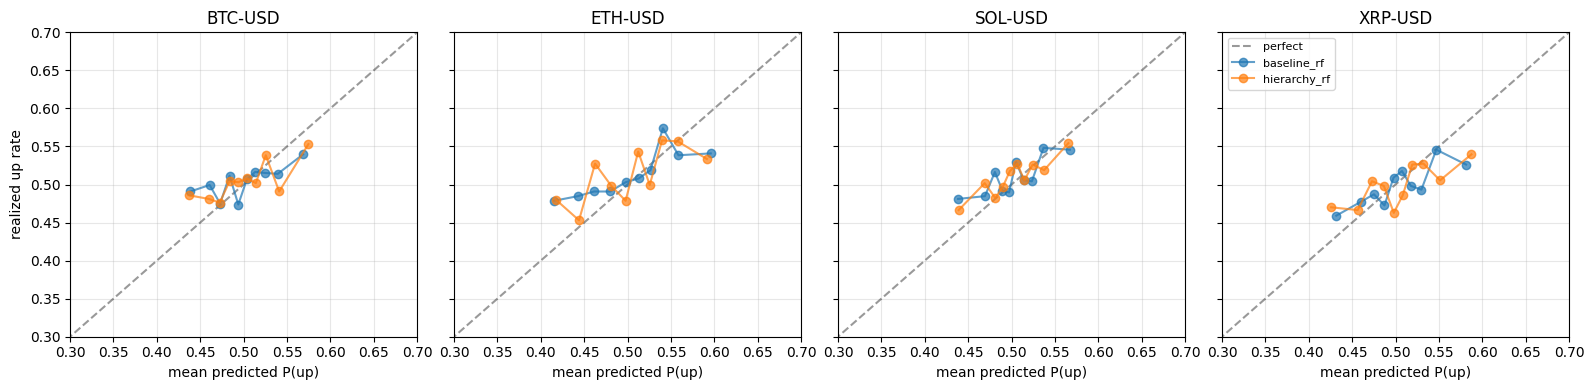

In [7]:
fig, axes = plt.subplots(1, len(TICKERS), figsize=(4 * len(TICKERS), 4), sharey=True)
for ax, tk in zip(axes, TICKERS):
    pps_h, ys = [], []
    pps_b = []
    for p in all_preds_by_ticker[tk]:
        pps_h.append(p["pp_h"]); pps_b.append(p["pp_b"]); ys.append(p["y_c"])
    pp_h = np.concatenate(pps_h); pp_b = np.concatenate(pps_b); y = np.concatenate(ys)
    df_h = pd.DataFrame({"pp": pp_h, "y": y, "bin": pd.qcut(pp_h, q=10, duplicates="drop")})
    df_b = pd.DataFrame({"pp": pp_b, "y": y, "bin": pd.qcut(pp_b, q=10, duplicates="drop")})
    g_h = df_h.groupby("bin", observed=True).agg(mean_pp=("pp", "mean"), up_rate=("y", "mean")).reset_index()
    g_b = df_b.groupby("bin", observed=True).agg(mean_pp=("pp", "mean"), up_rate=("y", "mean")).reset_index()
    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfect")
    ax.plot(g_b["mean_pp"], g_b["up_rate"], "o-", label="baseline_rf", alpha=0.7)
    ax.plot(g_h["mean_pp"], g_h["up_rate"], "o-", label="hierarchy_rf", alpha=0.7)
    ax.set_title(tk); ax.set_xlabel("mean predicted P(up)"); ax.grid(True, alpha=0.3)
    ax.set_xlim(0.3, 0.7); ax.set_ylim(0.3, 0.7)
    if ax is axes[0]: ax.set_ylabel("realized up rate")
axes[-1].legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()


## Append to EXPERIMENTS.md


In [8]:
def append_to_journal(agg_df, journal_path=JOURNAL_PATH):
    timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    config = {
        "notebook": "09_hourly_multi_crypto_walkforward.ipynb",
        "tickers": TICKERS, "period": PERIOD, "interval": INTERVAL,
        "horizon_hours": HORIZON, "n_folds": N_FOLDS,
        "max_hierarchy_depth": MAX_HIERARCHY_DEPTH,
        "min_leaf_count": MIN_LEAF_COUNT,
        "rf_n_estimators": RF_N_ESTIMATORS, "rf_grid": RF_GRID, "seed": SEED,
    }

    reg_summary = summarize_by_ticker(agg_df, "regression")
    cls_summary = summarize_by_ticker(agg_df, "classification")

    # Lift tables
    reg_lift = []
    cls_lift = []
    for tk in TICKERS:
        sub_r = agg_df[(agg_df["ticker"] == tk) & (agg_df["kind"] == "regression")]
        sub_c = agg_df[(agg_df["ticker"] == tk) & (agg_df["kind"] == "classification")]
        b_ic = sub_r[sub_r["model"] == "baseline_rf"]["ic"]
        h_ic = sub_r[sub_r["model"] == "hierarchy_rf"]["ic"]
        b_ba = sub_c[sub_c["model"] == "baseline_rf"]["balanced_accuracy"]
        h_ba = sub_c[sub_c["model"] == "hierarchy_rf"]["balanced_accuracy"]
        b_auc = sub_c[sub_c["model"] == "baseline_rf"]["roc_auc"]
        h_auc = sub_c[sub_c["model"] == "hierarchy_rf"]["roc_auc"]
        reg_lift.append({
            "ticker": tk,
            "baseline_ic": f"{b_ic.mean():.5f}",
            "hierarchy_ic": f"{h_ic.mean():.5f}",
            "ic_lift": f"{h_ic.mean() - b_ic.mean():+.5f}",
            "hier_ic_positive_folds": f"{int((h_ic > 0).sum())}/{len(h_ic)}",
        })
        cls_lift.append({
            "ticker": tk,
            "baseline_bal_acc": f"{b_ba.mean():.4f}",
            "hierarchy_bal_acc": f"{h_ba.mean():.4f}",
            "bal_acc_lift_pp": f"{(h_ba.mean() - b_ba.mean())*100:+.2f}",
            "baseline_auc": f"{b_auc.mean():.4f}",
            "hierarchy_auc": f"{h_auc.mean():.4f}",
            "hier_above_50pct_folds": f"{int((h_ba > 0.5).sum())}/{len(h_ba)}",
        })

    parts = []
    parts.append("\n---\n")
    parts.append(f"\n## {timestamp} — NB09 multi-crypto hourly robustness (1h horizon, K=4, 5-fold WF)\n")
    parts.append(f"\n**Config**\n\n```json\n{json.dumps(config, indent=2)}\n```\n")
    parts.append("\n**IC lift per ticker (regression)**\n\n")
    parts.append(pd.DataFrame(reg_lift).to_markdown(index=False))
    parts.append("\n\n**Direction lift per ticker (classification)**\n\n")
    parts.append(pd.DataFrame(cls_lift).to_markdown(index=False))
    parts.append("\n\n**Regression summary (mean ± std across folds, per ticker)**\n\n")
    parts.append("```\n"); parts.append(str(reg_summary)); parts.append("\n```\n")
    parts.append("\n**Classification summary (mean ± std across folds, per ticker)**\n\n")
    parts.append("```\n"); parts.append(str(cls_summary)); parts.append("\n```\n")
    text = "".join(parts)
    with open(journal_path, "a") as f:
        f.write(text)
    print(f"Appended entry to {journal_path}")
    return text


journal_text = append_to_journal(agg)


Appended entry to EXPERIMENTS.md


## How to read this

For the NB08 finding to be robust:

- IC lift `hierarchy − baseline` should be positive on ≥ 3 of 4 tickers.
- Hierarchy IC should be positive on ≥ 3 of 5 folds for each ticker.
- Balanced accuracy lift should be positive on ≥ 3 of 4 tickers; mean ≥ 50% on each.
- Calibration curves should be roughly monotonic and span more than ±2 pp around 50%.

If only BTC clears these bars, the NB08 result was ticker-specific. If 3+ tickers clear them, the hierarchy adds genuine intraday signal across crypto.
